In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself



startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)



In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_A_p=0.0
dev_B_p=0.0
dev_A_e=0.0
dev_B_e=0.0

evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5

print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_A_p,dev_B_p,dev_A_e,dev_B_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devAp":dev_A_p,
"devBp":dev_B_p,"devAe":dev_A_e,"devBe":dev_B_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,
            dev_A_p,dev_B_p,dev_A_e,dev_B_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included",'devAp','devBp','devAe','devBe']

True


should take p0 around for for true waveform:  7.406743573435626
separatrix p:  3.3636344376256564
[0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0]


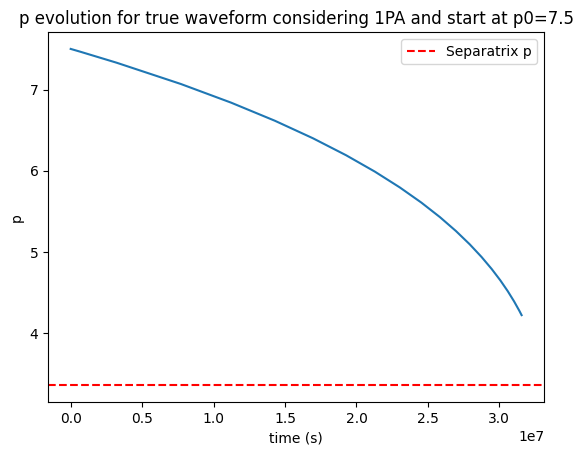

In [4]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_A_p,dev_B_p,dev_A_e,dev_B_e]
p_sep = get_separatrix(a, e0, xI0)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=1.0, traj_args=[m1, m2, a, e0, xI0, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_A_p,dev_B_p,dev_A_e,dev_B_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1, m2, a, p0, e0, xI0, *add_args,
                                               Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()



In [5]:

der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )

Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.5, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.80009024813492
calculating stable deltas...
Gamma_ii for m1: 22240.72151069398
Gamma_ii for m1: 22240.721510158546
Gamma_ii for m1: 22240.721510652977
Gamma_ii for m1: 22240.7215097721
Gamma_ii for m1: 22240.721508690618
Gamma_ii for m1: 22240.721538590584
Gamma_ii for m1: 22240.721477566345
Gamma_ii for m1: 22240.721214136785
Gamma_ii for m1: 22240.72014820061
Gamma_ii for m1: 22240.725148647558
[np.float64(2.4074492484625077e-11), np.float64(2.223086258588309e-11), np.float64(3.960655503416585e-11), np.float64(4.8626127055077683e-11), np.float64(1.3443793038367605e-09), np.float64(2.7438066133400183e-09), np.float64(1.1844470202773634e-08), np.float64(4.792723297250166e-08), np.float6

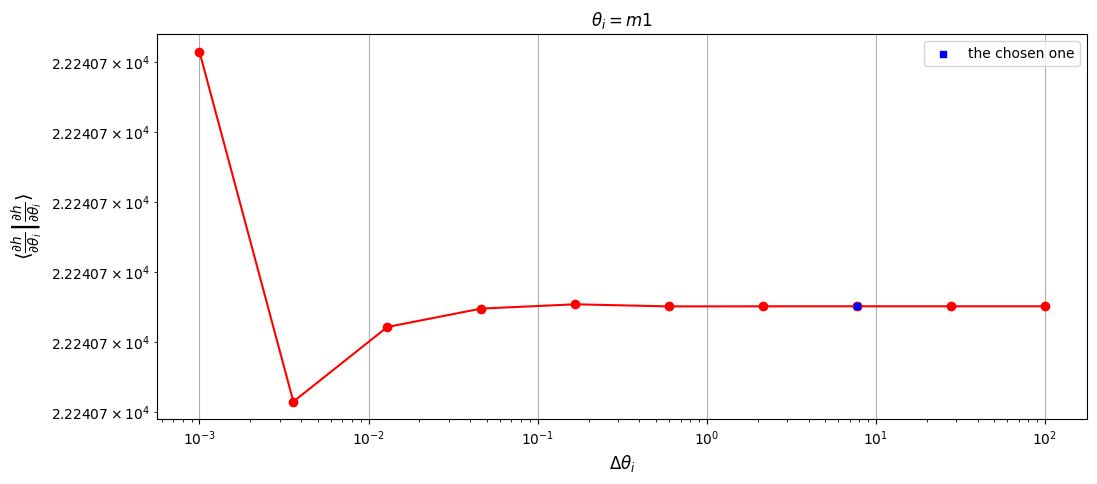

Gamma_ii for m2: 14181547972287.176
Gamma_ii for m2: 14181547971654.309
Gamma_ii for m2: 14181547974033.13
Gamma_ii for m2: 14181547964453.254
Gamma_ii for m2: 14181547985079.852
Gamma_ii for m2: 14181547970641.22
Gamma_ii for m2: 14181547948790.28
Gamma_ii for m2: 14181549043904.73
Gamma_ii for m2: 14181543864114.133
Gamma_ii for m2: 14181559104117.057
[np.float64(4.4626100674267555e-11), np.float64(1.6774066342973983e-10), np.float64(6.75517015288982e-10), np.float64(1.4544672893220731e-09), np.float64(1.0181279849890855e-09), np.float64(1.5408008692107506e-09), np.float64(7.722107421280316e-08), np.float64(3.652487096812863e-07), np.float64(1.0746352225407847e-06)]
0


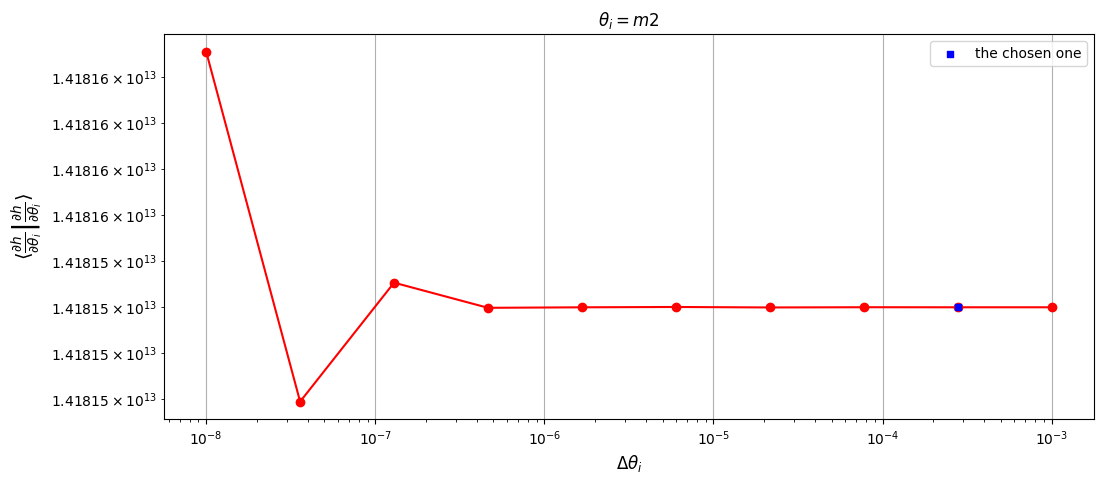

Gamma_ii for a: 1815068494978566.0
Gamma_ii for a: 1815068595031087.0
Gamma_ii for a: 1815068923336297.5
Gamma_ii for a: 1815065049201619.8
Gamma_ii for a: 1815088661907212.8
Gamma_ii for a: 1815051415267730.0
Gamma_ii for a: 1815202669447912.2
Gamma_ii for a: 1814909725370773.5
Gamma_ii for a: 1816653047456067.2
Gamma_ii for a: 1821386685535514.8
[np.float64(5.5123272626666974e-08), np.float64(1.80877544802287e-07), np.float64(2.1344329667160353e-06), np.float64(1.3009119658203827e-05), np.float64(2.0520983135486504e-05), np.float64(8.332633194521109e-05), np.float64(0.00016140972360424347), np.float64(0.0009596340301385531), np.float64(0.0025989198872702532)]
0


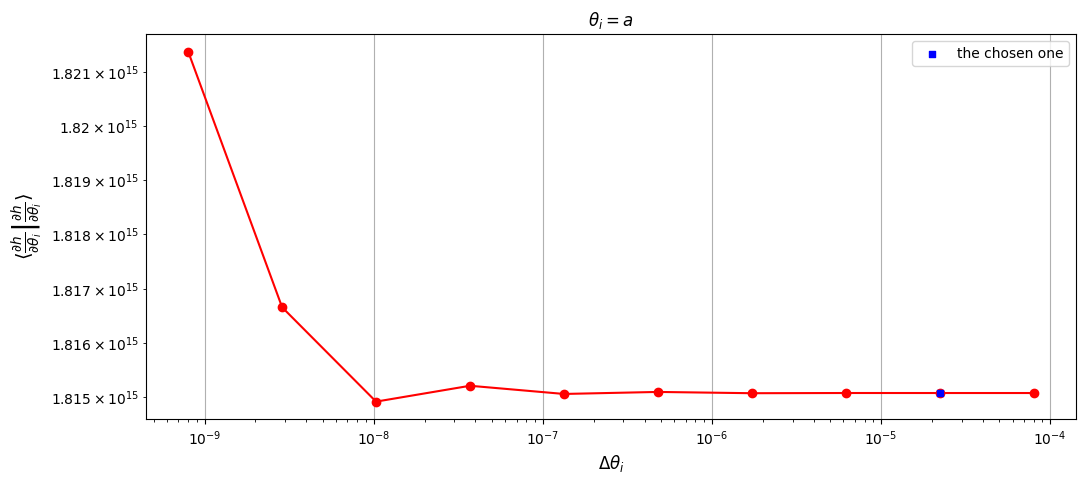

Gamma_ii for p0: 1172377805715645.2
Gamma_ii for p0: 1172377821846246.2
Gamma_ii for p0: 1172377859707287.2
Gamma_ii for p0: 1172378209719792.0
Gamma_ii for p0: 1172376289278271.0
Gamma_ii for p0: 1172380067892086.0
Gamma_ii for p0: 1172379451509869.8
Gamma_ii for p0: 1172404676064853.0
Gamma_ii for p0: 1172403261131592.8
Gamma_ii for p0: 1171556852506226.5
[np.float64(1.3758875935231978e-08), np.float64(3.229423064117991e-08), np.float64(2.985491387064042e-07), np.float64(1.6380760499534214e-06), np.float64(3.2230280251982326e-06), np.float64(5.25753172708871e-07), np.float64(2.1515228912183794e-05), np.float64(1.2068656810834179e-06), np.float64(0.0007224648326332517)]
0


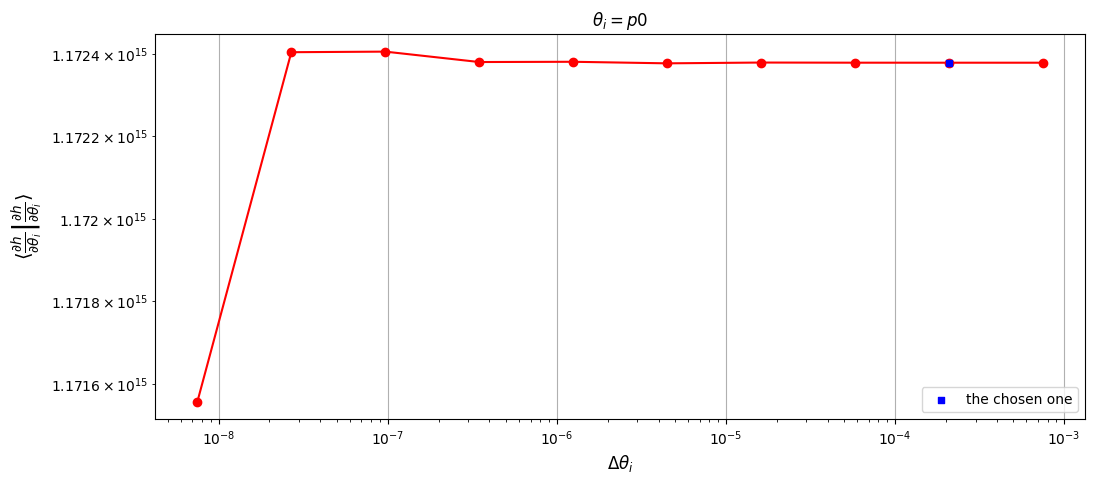

Gamma_ii for e0: 3816612863733878.0
Gamma_ii for e0: 3816613145112865.5
Gamma_ii for e0: 3816610244016562.0
Gamma_ii for e0: 3816600680985632.5
Gamma_ii for e0: 3816632513713348.0
Gamma_ii for e0: 3816570811170121.0
Gamma_ii for e0: 3816194432722876.0
Gamma_ii for e0: 3817413950844936.5
Gamma_ii for e0: 3813514580956628.5
Gamma_ii for e0: 3808975672493094.5
[np.float64(7.37247860345246e-08), np.float64(7.601238056854649e-07), np.float64(2.50564094303687e-06), np.float64(8.340527310691676e-06), np.float64(1.616701124643424e-05), np.float64(9.862664334334031e-05), np.float64(0.0003194618497662731), np.float64(0.001022513433613209), np.float64(0.001191634931226311)]
0


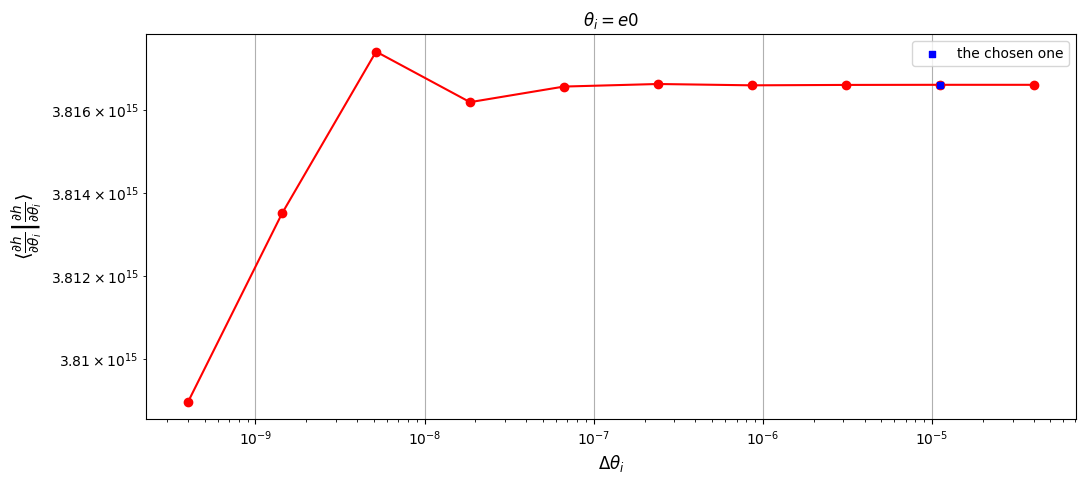

Gamma_ii for qS: 57465.02985506446
Gamma_ii for qS: 57465.02995124751
Gamma_ii for qS: 57465.02995125042
Gamma_ii for qS: 57465.02995125174
Gamma_ii for qS: 57465.029951242665
Gamma_ii for qS: 57465.029951235316
Gamma_ii for qS: 57465.029951125405
Gamma_ii for qS: 57465.0299512895
Gamma_ii for qS: 57465.02995234016
Gamma_ii for qS: 57465.02995336764
[np.float64(1.6737666719892084e-09), np.float64(5.064615903171632e-14), np.float64(2.2917386961851108e-14), np.float64(1.5788940078139695e-13), np.float64(1.2788155155511732e-13), np.float64(1.912652195836928e-12), np.float64(2.8555570616038034e-12), np.float64(1.828351664089803e-11), np.float64(1.7879993368500788e-11)]
2


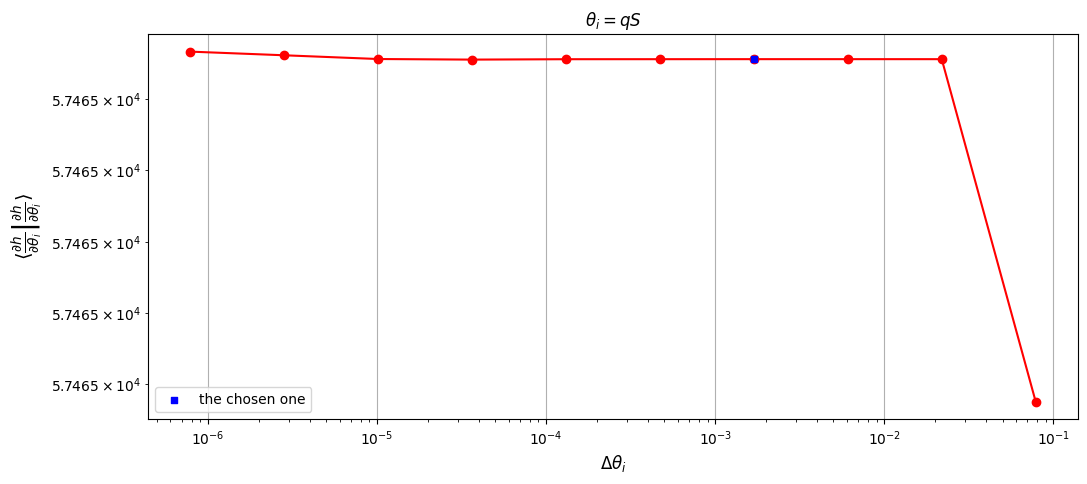

Gamma_ii for phiS: 1108978.3081460032
Gamma_ii for phiS: 1108978.3081097435
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097421
Gamma_ii for phiS: 1108978.3081097417
Gamma_ii for phiS: 1108978.3081097438
Gamma_ii for phiS: 1108978.3081097458
Gamma_ii for phiS: 1108978.3081096946
Gamma_ii for phiS: 1108978.3081097482
[np.float64(3.2696444279957465e-11), np.float64(1.2597035052059604e-15), np.float64(0.0), np.float64(0.0), np.float64(4.19901168401987e-16), np.float64(1.889555257808938e-15), np.float64(1.8895552578089344e-15), np.float64(4.618912852422053e-14), np.float64(4.828863436622822e-14)]
2


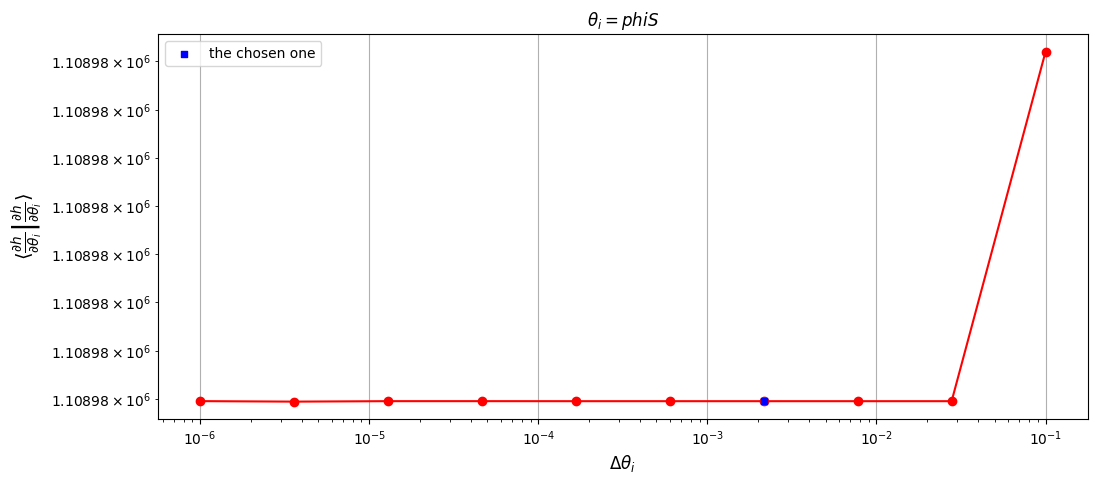

Gamma_ii for devAp: 102.32676063265468
Gamma_ii for devAp: 122.6231071639811
Gamma_ii for devAp: 163.59099870044057
Gamma_ii for devAp: 4783.687844347919
Gamma_ii for devAp: 46800.48228688168
Gamma_ii for devAp: 212208.07084197865
Gamma_ii for devAp: 7036127.542629846
Gamma_ii for devAp: 11181444.605811154
Gamma_ii for devAp: 60955941.818860784
Gamma_ii for devAp: 1030980113.1507573
[np.float64(0.16551812297648416), np.float64(0.2504287635744419), np.float64(0.9658023257320754), np.float64(0.897785501118889), np.float64(0.779459461173219), np.float64(0.9698402182796899), np.float64(0.3707317980207073), np.float64(0.8165651407858088), np.float64(0.9408757346127904)]
0
minimum relative error is greater than 1% for devAp. Fisher may be unstable!


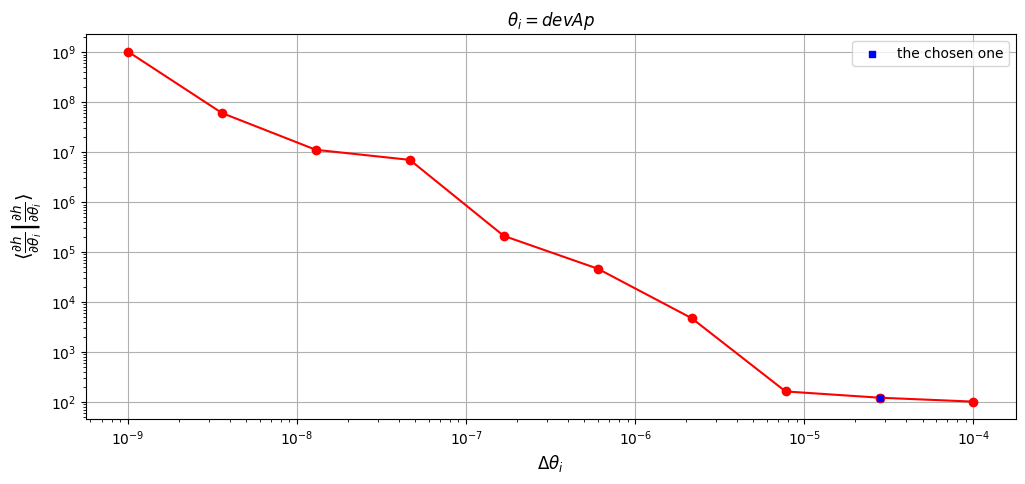

Gamma_ii for devAe: 0.8774662660129063
Gamma_ii for devAe: 4.227550882858086
Gamma_ii for devAe: 206.47200283445207
Gamma_ii for devAe: 353.6904212107289
Gamma_ii for devAe: 2185.595631820788
Gamma_ii for devAe: 183651.35111158452
Gamma_ii for devAe: 784067.0279631878
Gamma_ii for devAe: 17132115.537269816
Gamma_ii for devAe: 159838325.82130647
Gamma_ii for devAe: 680669560.4118234
[np.float64(0.7924409923554403), np.float64(0.9795248226160342), np.float64(0.4162352428780197), np.float64(0.8381720680343443), np.float64(0.9880992128912091), np.float64(0.7657708530498146), np.float64(0.9542340800669071), np.float64(0.8928159723317991), np.float64(0.7651748585251852)]
2
minimum relative error is greater than 1% for devAe. Fisher may be unstable!


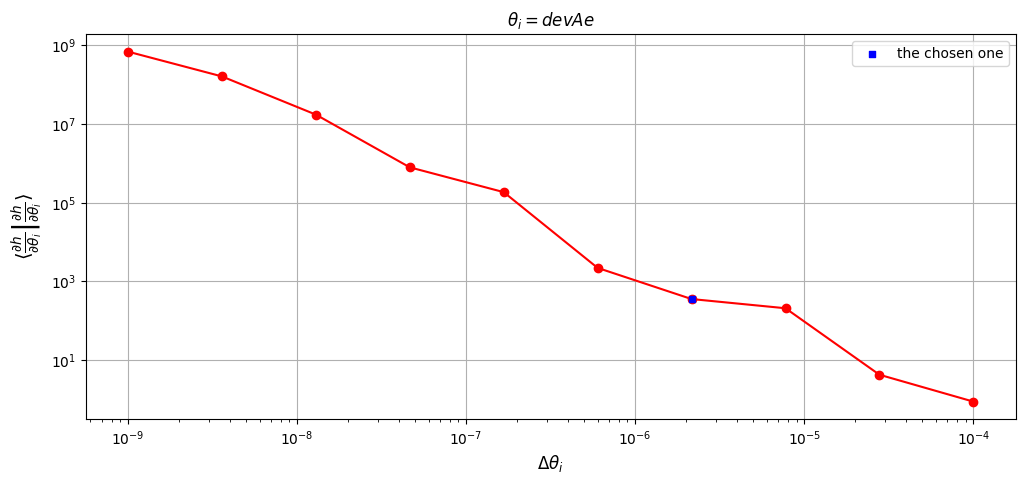

Gamma_ii for devBp: 4.444762686576916
Gamma_ii for devBp: 19.27110388337332
Gamma_ii for devBp: 32.16539085525154
Gamma_ii for devBp: 763.6373123826171
Gamma_ii for devBp: 5530.05086047393
Gamma_ii for devBp: 167647.6501170814
Gamma_ii for devBp: 2432545.9784078547
Gamma_ii for devBp: 92276250.153879
Gamma_ii for devBp: 258156238.17098263
Gamma_ii for devBp: 172867828.98437086
[np.float64(0.7693560932743579), np.float64(0.40087456203794297), np.float64(0.9578787071641476), np.float64(0.8619113401215315), np.float64(0.9670138480520791), np.float64(0.9310814054060306), np.float64(0.9736384392045475), np.float64(0.642556574237178), np.float64(0.49337351945527574)]
1
minimum relative error is greater than 1% for devBp. Fisher may be unstable!


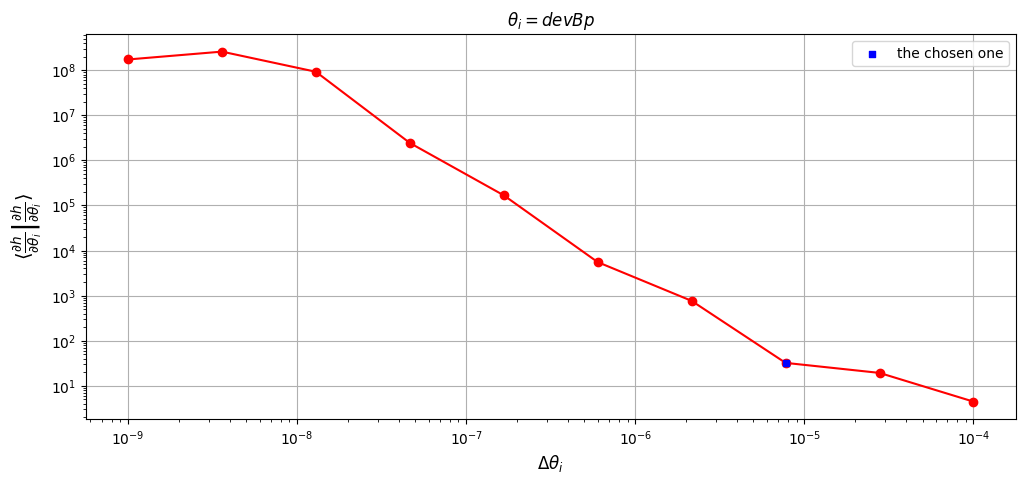

Gamma_ii for devBe: 0.07375498806236537
Gamma_ii for devBe: 6.541573984982662
Gamma_ii for devBe: 32.46750130310708
Gamma_ii for devBe: 2174.3066080704166
Gamma_ii for devBe: 2650.3106289639113
Gamma_ii for devBe: 307332.502052316
Gamma_ii for devBe: 2375017.686088219
Gamma_ii for devBe: 19894560.68808249
Gamma_ii for devBe: 53532950.34323784
Gamma_ii for devBe: 40977.09142326158
[np.float64(0.9887251924029777), np.float64(0.7985193278684293), np.float64(0.9850676527484226), np.float64(0.17960310602519053), np.float64(0.9913764062985022), np.float64(0.8705978048700307), np.float64(0.8806197471095235), np.float64(0.628367938614922), np.float64(1305.4116676872932)]
3
minimum relative error is greater than 1% for devBe. Fisher may be unstable!


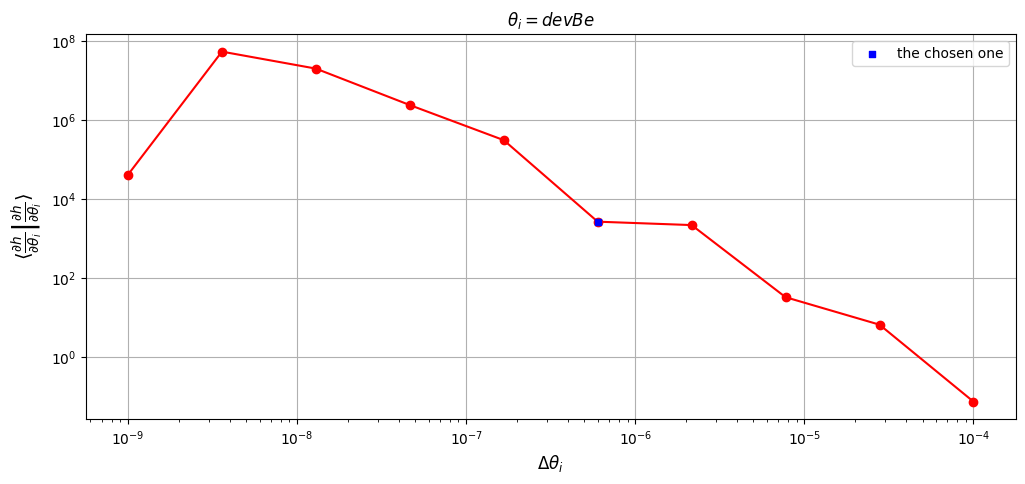

stable deltas: {'m1': 7.742636826811269, 'm2': 0.0002782559402207126, 'a': 2.2260475217657015e-05, 'p0': 0.00020869195516553445, 'e0': 1.1130237608828506e-05, 'qS': 0.0016920890487107918, 'phiS': 0.002154434690031882, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devAp': 2.782559402207126e-05, 'devAe': 2.1544346900318822e-06, 'devBp': 7.742636826811277e-06, 'devBe': 5.994842503189409e-07}
Time taken to compute stable deltas is 252.3888967037201 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 26.752811193466187 seconds


In [6]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,
                "devAp":dev_A_p,"devBp":dev_B_p,"devAe":dev_A_e,"devBe":dev_B_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devAp','devAe','devBp','devBe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )

In [7]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_A_p,dev_A_e,dev_B_p,dev_B_e])

In [8]:
chi2=0
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,
            dev_A_p,dev_A_e,dev_B_p,dev_B_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
waveform_true=xp.array(waveform_true)
waveform_true



[0, True, False, False, True, 0.0, 0.0, 0.0, 0.0]


array([[ 7.59702251e-22,  6.60831832e-22,  5.20017131e-22, ...,
        -7.08050729e-22, -4.50889192e-22, -1.48300466e-22],
       [-2.23474599e-22, -4.11084661e-22, -5.56564534e-22, ...,
         5.16737452e-22,  7.26660081e-22,  8.20565965e-22]],
      shape=(2, 3155815))

In [9]:
chi2=0
deviation_included=True
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,
            dev_A_p,dev_A_e,dev_B_p,dev_B_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev_A_p_,dev_A_e_,dev_B_p_,dev_B_e_):
    add_args__ = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,\
                dev_A_p_,dev_A_e_,dev_B_p_,dev_B_e_]
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS_, phiS_, qK,
                        phiK, Phi_phi0_, Phi_theta0, Phi_r0_, *add_args__, dt=dt, T=T,use_gpu=use_gpu))

    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner * 100


In [16]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev_A_p,dev_A_e,dev_B_p,dev_B_e = params[i]
        m1_ = np.exp(logm1_)

        loglike = loglike_calc(m1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev_A_p,dev_A_e,dev_B_p,dev_B_e)
        log_likes[i] = loglike 
    return log_likes

n=20

logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]
qSlim = [params_truth_in[5] - n*std[5], params_truth_in[5] + n*std[5]]
phiSlim = [params_truth_in[6] - n*std[6], params_truth_in[6] + n*std[6]]
Phi_phi0lim = [params_truth_in[7] - n*std[7], params_truth_in[7] + n*std[7]]
Phi_r0lim = [params_truth_in[8] - n*std[8], params_truth_in[8] + n*std[8]]
devAplim = [params_truth_in[9] - n*std[9], params_truth_in[9] + n*std[9]]
devAelim = [params_truth_in[10] - n*std[10], params_truth_in[10] + n*std[10]]
devBplim = [params_truth_in[11] - n*std[11], params_truth_in[11] + n*std[11]]
devBelim = [params_truth_in[12] - n*std[12], params_truth_in[12] + n*std[12]]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]

    # Linear in others 
    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    transformed[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    transformed[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    transformed[:, 7] = (Phi_phi0lim[1] - Phi_phi0lim[0]) * u[:, 7] + Phi_phi0lim[0]
    transformed[:, 8] = (Phi_r0lim[1] - Phi_r0lim[0]) * u[:, 8] + Phi_r0lim[0]
    transformed[:, 9] = (devAplim[1] - devAplim[0]) * u[:, 9] + devAplim[0]
    transformed[:, 10] = (devAelim[1] - devAelim[0]) * u[:, 10] + devAelim[0]
    transformed[:, 11] = (devBplim[1] - devBplim[0]) * u[:, 11] + devBplim[0]
    transformed[:, 12] = (devBelim[1] - devBelim[0]) * u[:, 12] + devBelim[0]

    return transformed

    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (x[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 7] = (x[:, 7] - Phi_phi0lim[0]) / (Phi_phi0lim[1] - Phi_phi0lim[0])
    u[:, 8] = (x[:, 8] - Phi_r0lim[0]) / (Phi_r0lim[1] - Phi_r0lim[0])
    u[:, 9] = (x[:, 9] - devAplim[0]) / (devAplim[1] - devAplim[0])
    u[:, 10] = (x[:, 10] - devAelim[0]) / (devAelim[1] - devAelim[0])
    u[:, 11] = (x[:, 11] - devBplim[0]) / (devBplim[1] - devBplim[0])
    u[:, 12] = (x[:, 12] - devBelim[0]) / (devBelim[1] - devBelim[0])
    
    return u

## Deviation parameters in this case are not scaled


In [ ]:
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=5000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 13  # Number of parameters
n_seed = 100 
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_manin_t_3'  # Directory to save results

os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
print("Preparing LHS samples...")


true_point = np.array([[0.54275643, 0.58256216, 0.56339224, 0.46273953, 0.43972752,
        0.50427994, 0.50024962, 0.53067437, 0.38606556, 0.31278788,
        0.25309632, 0.64173643, 0.36038196]])

scatter = 1.0e-7
points = true_point + np.random.randn(99, 13) * scatter
# Add the original point as the 100th row
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


sampler.run_sampling(
            num_iterations=int(1e5),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.01
        )

print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")

Problem dimension: 13
Number of processes: 100
Save path: paris_manin_t_3
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
Shape of points array: (100, 13)
true points in corrrect space [13.81551056 10.          0.8         7.5         0.4         0.78539816
  1.          0.9         0.4         0.          0.          0.
  0.        ]
external_lhs_log_densities [-1528.15945996 -1526.90650332 -1526.95149428 -1528.95423469
 -1528.50731304 -1526.67913655 -1526.54387795 -1528.07560054
 -1528.17577292 -1527.92120842 -1526.10885868 -1527.66666566
 -1528.62352055 -1528.29955566 -1529.13904756 -1528.93399602
 -1527.42083469 -1527.05499539 -1527.0961225  -1526.94845508
 -1528.59991744 -1527.11453123 -1528.58738193 -1526.89835917
 -1528.09728117 -1528.85563077 -1527.3914161  -1527.93473615
 -1527.61581958 -1527.88211577 -1525.68536006 -1527.96831512
 -1529.09659887 -1527.33246549 -1527.07709238 -1528.4924776
 -1527.3274609  -1529.11952595 -1528.89688977 -1527.05252096
 -

Sampling:   0%|          | 0/99999 [00:00<?, ?it/s]

/home/svu/e1583490/scratch/parismc/parismc/sampler.py:789: RuntimeWarning: divide by zero encountered in log
  logZ = c_term - np.log(Nsum) + np.log(wsum)
/home/svu/e1583490/scratch/parismc/parismc/sampler.py:789: RuntimeWarning: invalid value encountered in scalar add
  logZ = c_term - np.log(Nsum) + np.log(wsum)


: 

In [ ]:
best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
print(np.max(external_lhs_log_densities))
print(best_fit_tn)

prior_transform(np.array([best_fit_tn]))

In [17]:
print(log_density([params_truth_in]))
log_density([[13.81553722, 10.00030825,  0.8000271 ,  7.49990236,  0.39999168,  0.7877274 ,
  1.00017181,  0.98633795,  0.3175935 , -9.3613611 , -1.73371196,  4.17279803,
 -0.32676721]])

[-186161.8908842]


array([-1527.68781994])

In [18]:
inverse_prior_transform(np.array([[13.81553722, 10.00030825,  0.8000271 ,  7.49990236,  0.39999168,  0.7877274 ,
  1.00017181,  0.98633795,  0.3175935 , -9.3613611 , -1.73371196,  4.17279803,
 -0.32676721]]))

array([[0.54275643, 0.58256216, 0.56339224, 0.46273953, 0.43972752,
        0.50427994, 0.50024962, 0.53067437, 0.38606556, 0.31278788,
        0.25309632, 0.64173643, 0.36038196]])

# array([-265.31153322])
## [13.81550908,  9.99999556,  0.80000174,  7.50000459,  0.39999946,  0.78014269,0.99989983,  0.89753954,  0.40143766,  0.21762477, -0.02574393,  0.04729688,0.02035483]

#
## [13.81550554,  9.99998765,  0.80000436,  7.50001092,  0.40000217,  0.77474496,1.00780145,  0.86193575,  0.38736127,  0.03437416, -0.21992583, -0.61558069, 0.02428799]